# Make several plots comparing different results

In [1]:
main_llm_dir = '/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/'
# which specific subdirectories do we want to parse?
dirs_to_use = ['chatgpt_api/', 'chatgpt_api_highR_lowVerbose/', 'chatgpt_api_highR_lowVerbose_mini/', 'gemini/', 'claude_haiku/']

# full baseline data stored
dir_jsons = '/Users/jnaiman/Dropbox/jcdl_followup/synthetic_figures/qa_jsons/'

save_fig_dir = '/Users/jnaiman/Dropbox/jcdl_followup/paper_figures/'

In [2]:
from glob import glob
import pickle
import pandas as pd
import json
from copy import deepcopy
import numpy as np
import os
import matplotlib.pyplot as plt
from Levenshtein import distance as levenshtein_distance # Assuming you have python-Levenshtein installed

# debug
from importlib import reload

import seaborn as sns
import numpy as np

In [3]:
def track_questions(questions_figure, df, df_question_tags, ignore_special = False):
    df_F_question_tags = {}
    for k,v in df_question_tags.items():
        df_F_question_tags[k] = []
    # also track questions
    for qa in questions_figure:
        if ignore_special and qa['type'] == 'special':
            continue
        dfsub = df[df['question']==qa['question']]
        df_F_question_tags['tag'].append(qa['tag'].replace('#', '\\#'))
        df_F_question_tags['question'].append(qa['question'].replace('#', '\\#'))
        level = np.unique(dfsub['Level'])[0].split('Level')[-1].replace(' ','')
        df_F_question_tags['Level'].append(level)
        ltype = np.unique(dfsub['Level Type'])[0].split('-level questions')[0]
        df_F_question_tags['Type'].append(ltype)
    return df_F_question_tags

In [4]:
import utils.results_plotting_utils
reload(utils.results_plotting_utils)
from utils.results_plotting_utils import get_dirs_names_files

dirnames, dirs, files_parsed = get_dirs_names_files(main_llm_dir, 
        dirs_to_use, 
        replace_names = {'chatgpt_api':'ChatGPT', 
                        'chatgpt_api_highR_lowVerbose':'ChatGPT-HR',
                        'chatgpt_api_highR_lowVerbose_mini':'ChatGPT-HR-mini', 
                        'gemini':'Gemini'},
        verbose=True)

# dirs_tmp = glob(main_llm_dir + '*')
# dirs_tmp

DIRS:
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/gemini
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/chatgpt_api_mini
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/claude_haiku
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/chatgpt_api_old
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/chatgpt_api_highR_lowVerbose
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/chatgpt_api
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/chatgpt_api_highR_lowVerbose_mini

ONLY USED DIRNAMES, DIRS
ChatGPT ,  /Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/chatgpt_api/
ChatGPT-HR ,  /Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/chatgpt_api_highR_lowVerbose/
ChatGPT-HR-mini ,  /Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/chatgpt_api_highR_lowVerbose_mini/
Gemini ,  /Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/gemini/
claude_haiku ,  /Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/claude_haiku/

there are: 24 overlapping files so far


In [5]:
import utils.parse_lmm_output_utils
reload(utils.parse_lmm_output_utils)

from utils.parse_lmm_output_utils import parse_json_files

df = parse_json_files(dirnames, dirs, files_parsed, dir_jsons, 
                     verbose=True, use_explanation=True)


****************************************
*********** ChatGPT ****************
****************************************

----------- Picture_000067_qa.pickle ------------
9:18
[ERROR]: different types of values, could not fix:
  GT: -9.285323670614062 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean y": ""}

----------- Picture_000077_qa.pickle ------------
[ERROR]: different types of values, could not fix:
  GT: 4.561426392275432 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean x": ""}

----------- Picture_000116_qa.pickle ------------
1.97:1
[ERROR]: different types of values, could not fix:
  GT: -12.311367476438452 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"median color": ""}

----------- Picture_000180_qa.pickle ------------
3.0:4.0
----------- Picture_000083_qa.pickle ------------
1.33:1
----------- Picture_000130_qa.pickle ------------
1.77:1
[ERROR]: different types of values, could not fix:
  GT: 1491423.8486516487 <class 'float'>
  LLM:  <class 'str'>
  

<unknown>:1: SyntaxWarning: invalid escape sequence '\!'
<unknown>:1: SyntaxWarning: invalid escape sequence '\!'


1680:1100
----------- Picture_000164_qa.pickle ------------
4:5
----------- Picture_000058_qa.pickle ------------
8:3

****************************************
*********** Gemini ****************
****************************************

----------- Picture_000067_qa.pickle ------------
1:5.5
----------- Picture_000077_qa.pickle ------------
606:1324
----------- Picture_000116_qa.pickle ------------
1.57:1
----------- Picture_000180_qa.pickle ------------
2:3
----------- Picture_000083_qa.pickle ------------
----------- Picture_000130_qa.pickle ------------
3:2
----------- Picture_000120_qa.pickle ------------
2.4:1
----------- Picture_000152_qa.pickle ------------
0.6:1
----------- Picture_000189_qa.pickle ------------
4:3
----------- Picture_000190_qa.pickle ------------
1797:1600
----------- Picture_000093_qa.pickle ------------
1:4.75
----------- Picture_000041_qa.pickle ------------
956:1332
----------- Picture_000106_qa.pickle ------------
1:5.1
----------- Picture_000139_qa.pick

<unknown>:1: SyntaxWarning: invalid escape sequence '\ '
<unknown>:1: SyntaxWarning: invalid escape sequence '\ '
<unknown>:1: SyntaxWarning: invalid escape sequence '\l'
<unknown>:1: SyntaxWarning: invalid escape sequence '\s'
<unknown>:4: SyntaxWarning: invalid escape sequence '\s'
<unknown>:2: SyntaxWarning: invalid escape sequence '\s'
<unknown>:1: SyntaxWarning: invalid escape sequence '\ '
<unknown>:1: SyntaxWarning: invalid escape sequence '\ '
<unknown>:2: SyntaxWarning: invalid escape sequence '\m'
<unknown>:1: SyntaxWarning: invalid escape sequence '\c'
<unknown>:1: SyntaxWarning: invalid escape sequence '\e'
<unknown>:1: SyntaxWarning: invalid escape sequence '\e'


[ERROR]: missing key: plot style
  question format: Please format the output as a json as {"plot style":""} to store the matplotlib plotting style used in the figure.
  GT: {'plot style': 'fivethirtyeight'}
  LMM: {'plot_style': 'default'}
  raw LMM: {"plot_style": "default"}

16:9
[ERROR]: missing key: maximum x
  question format: Please format the output as a json as {"maximum x":""} for this figure panel, where the "maximum x" value should be a float, calculated from the data values used to create the plot.
  GT: {'maximum x': 132444016558.88988}
  LMM: {'maximum_value': 90}
  raw LMM: {"maximum_value": 90}

----------- Picture_000093_qa.pickle ------------
[ERROR]: missing key: plot style
  question format: Please format the output as a json as {"plot style":""} to store the matplotlib plotting style used in the figure.
  GT: {'plot style': 'default'}
  LMM: {'plot_style': 'classic'}
  raw LMM: {"plot_style": "classic"}

1:2.5
[ERROR]: missing key: line styles
  question format: Pl

In [6]:
df.head()

,image id,plot number,plot type,question,use list,model,model id,LMM Answer,GT Answer,Level,Level Type,Explanation
0,Picture_000067_qa,NaN,None,How many panels are in this figure?,False,ChatGPT,gpt-5.4-nano-2026-03-17,"{'nrows': 6, 'ncols': 1}","{'nrows': 5, 'ncols': 1}",Level 1,Figure-level questions,{'explanation': 'The figure is a vertical stac...
1,Picture_000067_qa,NaN,None,What is the plot style used in this figure?,False,ChatGPT,gpt-5.4-nano-2026-03-17,{'plot style': 'ggplot'},{'plot style': 'seaborn-v0_8-bright'},Level 1,Figure-level questions,{'explanation': 'The figure uses the ggplot-li...
2,Picture_000067_qa,NaN,None,What is the colormap that was used in this fig...,False,ChatGPT,gpt-5.4-nano-2026-03-17,{'colormap': 'Blues'},{'colormap': 'Blues'},Level 1,Figure-level questions,{'explanation': 'The figure contains multiple ...
3,Picture_000067_qa,NaN,None,What is the aspect ratio of this figure?,False,ChatGPT,gpt-5.4-nano-2026-03-17,{'aspect ratio': 0.5},{'aspect ratio': 1.2709038828156305},Level 1,Figure-level questions,"{'explanation': 'The image is a tall, multi-pa..."
4,Picture_000067_qa,NaN,None,What are the titles for each figure panel?,False,ChatGPT,gpt-5.4-nano-2026-03-17,"{'titles': ['', '', 'Citations (\bar{\sigma}_0...","{'titles': ['', '', '', 'Relies', '']}",Level 1,Figure-level questions,{'explanation': 'The figure is a vertical stac...


In [7]:
import utils.parse_lmm_output_utils
reload(utils.parse_lmm_output_utils)

from utils.parse_lmm_output_utils import get_lmm_gt

df_question_tags = {}
for t in ['tag', 'question', 'Level', 'Type']:
    df_question_tags[t] = []

# Figure-level Questions

In [8]:
figure_level_questions = df[df['Level Type']=='Figure-level questions']['question'].unique()
#figure_level_questions1 = df[df['Level Type']=='Figure-level questions']['question'].unique()
# # filter out addition of numbers/lists
# figure_level_questions = []
# for f in figure_level_questions1:
#     if 'Please choose from ' in f:
#         figure_level_questions.append(f.split('Please choose from ')[0].rstrip().lstrip())
#     else:
#         figure_level_questions.append(f)
# figure_level_questions = np.unique(figure_level_questions).tolist()
figure_level_questions

array(['How many panels are in this figure?',
       'What is the plot style used in this figure?',
       'What is the colormap that was used in this figure?',
       'What is the aspect ratio of this figure?',
       'What are the titles for each figure panel?',
       'What are the x-axis titles for each figure panel?',
       'What are the y-axis titles for each figure panel?',
       'What are the values for each of the tick marks on the x-axis?',
       'What are the values for each of the tick marks on the y-axis?',
       'What are the plot types for each panel in the figure?',
       'Which plot shows the largest median data values?',
       'Which plot shows the strongest linear relationship between its x and y values?'],
      dtype=object)

Of these, which do we want to calculate accuracies for, and how should accuracies be calculated?

In [9]:
questions_figure = [
    {'tag':'# panels', 'question':'How many panels are in this figure?', 'type':'special'}, # have to calculate this from answer
    {'tag':'plot style', 'question':'What is the plot style used in this figure?', 'type':'binary string'},
    {'tag':'plot type', 'question':'What are the plot types for each panel in the figure?', 'type':'binary string list', 'use list':True},
    {'tag':'colormap', 'question':'What is the colormap that was used in this figure?', 'type':'binary string'},
    {'tag':'aspect ratio', 'question':'What is the aspect ratio of this figure?', 'type':'float'},
    {'tag':'titles', 'question': 'What are the titles for each figure panel?', 'type':'string list'},
    {'tag':'x-labels', 'question': 'What are the x-axis titles for each figure panel?', 'type':'string list'},
    {'tag':'y-labels', 'question': 'What are the y-axis titles for each figure panel?', 'type':'string list'},
    # {'tag':'largest median', 'question':'Which plot shows the largest median data values?', 'type':'float'},
    # {'tag':'strongest linear', 'question':'Which plot shows the strongest linear relationship between its x and y values?', 'type':'float'},
]

In [10]:
reload(utils.results_plotting_utils)
reload(utils.parse_lmm_output_utils)
from utils.parse_lmm_output_utils import get_lmm_gt
from utils.results_plotting_utils import calculate_plot_accuracies

df_F_question_tags, dfplot1 = calculate_plot_accuracies(df,questions_figure, df_question_tags)

[WARNING]: have to delete GT to align
[WARNING]: have to delete GT to align
[WARNING]: have to delete GT to align
[WARNING]: have to delete GT to align
[WARNING]: have to delete GT to align


How many answers do we have per number of panels per figure?

In [11]:
dfpsort = dfplot1['# panels GT'].value_counts().sort_index()
dfpsort

# panels GT
1    15
2     5
3     1
5     3
Name: count, dtype: int64

For plotting, w/rt ground truth # of panels only take ones where count = X or more

In [12]:
count_cut = 2
panels_cut = dfpsort[dfpsort >= count_cut].index
print('only these panels:', np.array(panels_cut.values))

dfcut = dfplot1.copy()#[dfplot[dfplot['# panels GT']] >= panels_cut.max()]
dfcut = dfcut[dfcut['# panels GT'].isin(panels_cut)]
dfcut.head()

only these panels: [1 2 5]


,Tag,# panels GT,ChatGPT # panels,ChatGPT-HR # panels,ChatGPT-HR-mini # panels,Gemini # panels,claude_haiku # panels,ChatGPT plot style,ChatGPT-HR plot style,ChatGPT-HR-mini plot style,...,ChatGPT x-labels,ChatGPT-HR x-labels,ChatGPT-HR-mini x-labels,Gemini x-labels,claude_haiku x-labels,ChatGPT y-labels,ChatGPT-HR y-labels,ChatGPT-HR-mini y-labels,Gemini y-labels,claude_haiku y-labels
0,# panels,5,6,5,5,5,5,0,0,0,...,0.808219,0.794521,0.904110,0.904110,0.657534,0.161290,0.236559,0.451613,0.698925,0.161290
1,# panels,1,1,1,1,1,1,0,0,0,...,-0.571429,0.642857,0.857143,0.857143,0.857143,0.270270,0.324324,0.675676,0.729730,0.486486
2,# panels,2,2,2,2,2,2,0,0,0,...,0.554054,0.540541,0.689189,0.567568,0.662162,0.424658,0.424658,0.712329,0.794521,0.657534
3,# panels,1,1,1,1,1,1,0,0,0,...,0.608696,0.434783,0.326087,0.413043,0.239130,-1.562500,-0.187500,1.000000,1.000000,0.937500
4,# panels,1,1,1,1,1,1,0,0,0,...,0.954545,0.909091,1.000000,1.000000,1.000000,-0.333333,0.833333,1.000000,1.000000,1.000000


In [13]:
# fill marker sizes
marker_min = 15
marker_max = 65
colors_levels = ['darkblue', 'orange', 'cyan', 'green', 'magenta', 'deepskyblue', 'orangered', 'purple', 'gold', 'red']
#marker_sizes_levels = [55,35,15]


marker_sizes = {}
marker_sizes_levels = np.round(np.linspace(marker_min, marker_max, df['model'].nunique())).astype('int')[::-1]
for i,m in enumerate(df['model'].unique()):
    marker_sizes[m] = marker_sizes_levels[i]
# fill marker styles
marker_styles = {}
marker_styles_levels = ['s','o','^', 'D', 'X','*','h']
if df['model'].nunique() > len(marker_styles_levels):
    print('Not enough markers!')
    import sys; sys.exit()
for i,m in enumerate(df['model'].unique()):
    marker_styles[m] = marker_styles_levels[i]
# fill colors
colors = {}
if df['model'].nunique() > len(colors_levels):
    print('Not enough colors!')
    import sys; sys.exit()
for i,m in enumerate(df['model'].unique()):
    colors[m] = colors_levels[i]
# fill labels
labels = {}
labels_levels = []
for i,m in enumerate(df['model'].unique()):
    if len(labels_levels) < df['model'].nunique(): # not enough labels
        labels[m] = str(m)

In [14]:
reload(utils.results_plotting_utils)
from utils.results_plotting_utils import make_square_grid_figure, make_square_grid_figure_gs

In [15]:
dfplot1.columns

Index(['Tag', '# panels GT', 'ChatGPT # panels', 'ChatGPT-HR # panels',
       'ChatGPT-HR-mini # panels', 'Gemini # panels', 'claude_haiku # panels',
       'ChatGPT plot style', 'ChatGPT-HR plot style',
       'ChatGPT-HR-mini plot style', 'Gemini plot style',
       'claude_haiku plot style', 'ChatGPT plot type', 'ChatGPT-HR plot type',
       'ChatGPT-HR-mini plot type', 'Gemini plot type',
       'claude_haiku plot type', 'ChatGPT colormap', 'ChatGPT-HR colormap',
       'ChatGPT-HR-mini colormap', 'Gemini colormap', 'claude_haiku colormap',
       'ChatGPT aspect ratio', 'ChatGPT-HR aspect ratio',
       'ChatGPT-HR-mini aspect ratio', 'Gemini aspect ratio',
       'claude_haiku aspect ratio', 'ChatGPT titles', 'ChatGPT-HR titles',
       'ChatGPT-HR-mini titles', 'Gemini titles', 'claude_haiku titles',
       'ChatGPT x-labels', 'ChatGPT-HR x-labels', 'ChatGPT-HR-mini x-labels',
       'Gemini x-labels', 'claude_haiku x-labels', 'ChatGPT y-labels',
       'ChatGPT-HR y-labels', 

In [16]:
reload(utils.results_plotting_utils)
from utils.results_plotting_utils import add_kde_contours

/Users/jnaiman/LLM_VQA_MultiPanel/utils/results_plotting_utils.py:344: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()   # now works without warnings
/Users/jnaiman/LLM_VQA_MultiPanel/utils/results_plotting_utils.py:76: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(x=x_data, y=y_data, ax=ax, color=color,
/Users/jnaiman/LLM_VQA_MultiPanel/utils/results_plotting_utils.py:76: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(x=x_data, y=y_data, ax=ax, color=color,
/Users/jnaiman/LLM_VQA_MultiPanel/utils/results_plotting_utils.py:76: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(x=x_data, y=y_data, ax=ax, color=color,
/Users/jnaiman/LL

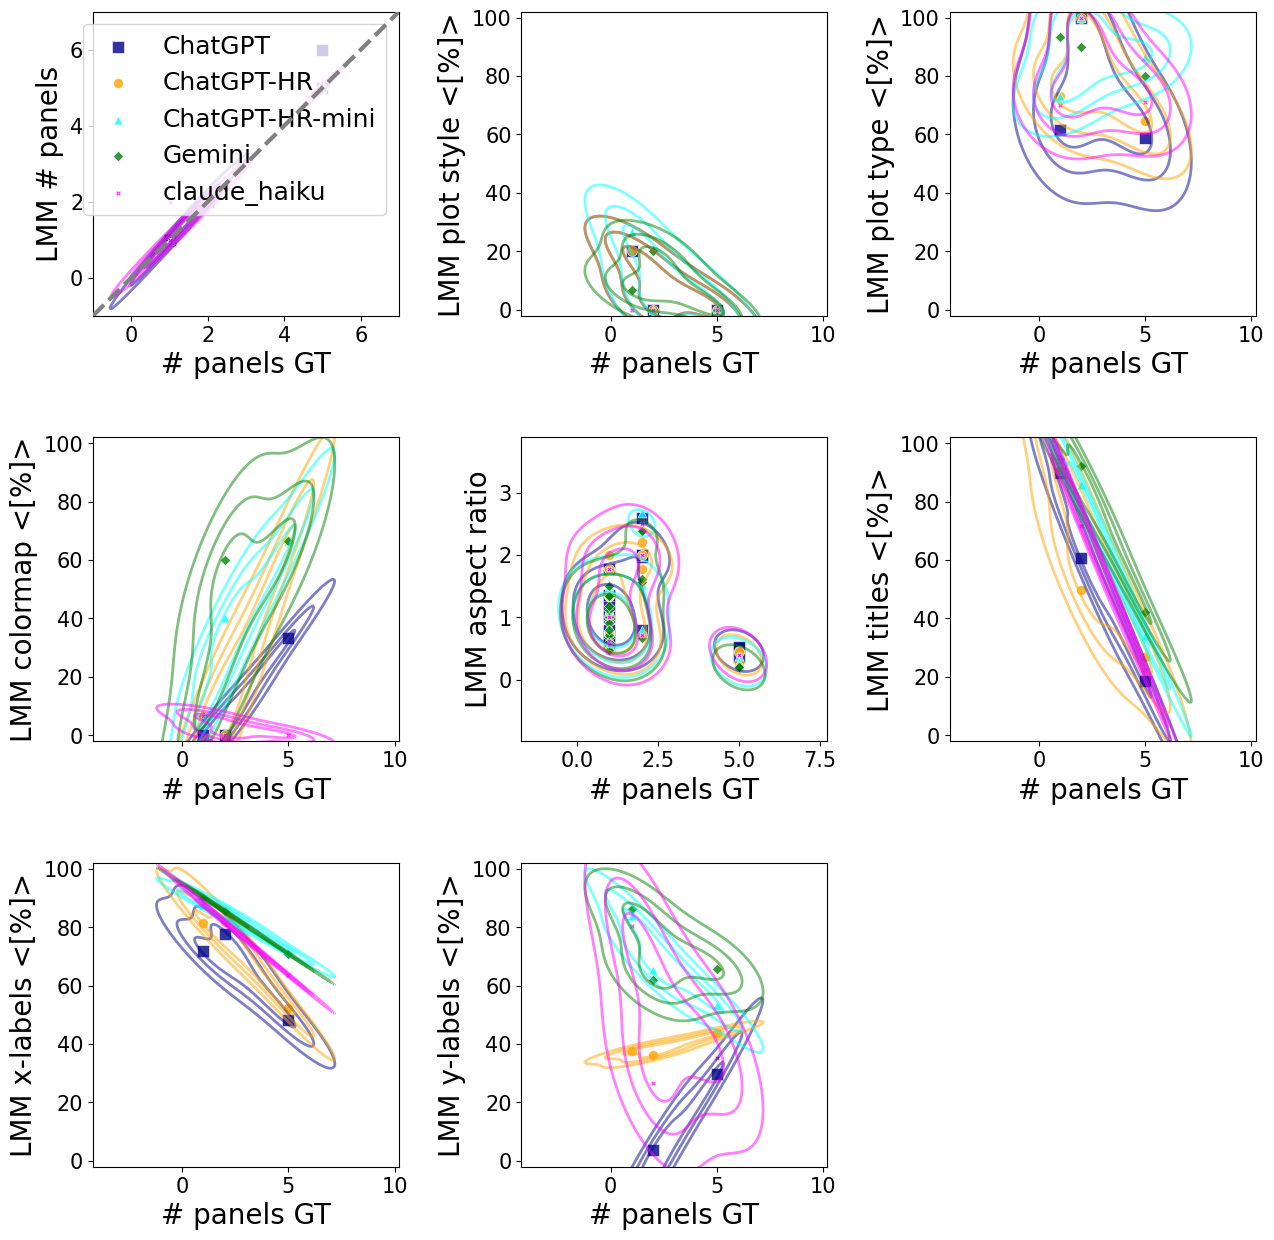

In [17]:
fixed_axis = '# panels GT'

base = 5
#nx = 1; ny = 3
#npanels = nx*ny
#fig, axes = plt.subplots(1,npanels, figsize=(base*npanels,base))
levels = [0.25, 0.5, 0.75]

fontsize = 20
tick_fontsize = 15
legend_fontsize = 18

eq_linethick = 3
eq_linestyle = '--'
eq_linecolor = 'gray'

plot_kde = True

# for plotting
dfplot = dfcut.copy()

fudge = 2

iqset = 0
plot_diffs = False
normalize_diff = False

questions_plot = questions_figure

specials = ['aspect ratio']
use_average_percent = True

fig, axes = make_square_grid_figure_gs(len(questions_plot), figsize_per_plot=(base,base))

for iq,q in enumerate(questions_plot):
    dfsub = df[df['question']==q['question']]

    for imodel, model in enumerate(dfsub['model'].unique()):

        #gttag = '# panels GT' # for fixed axis
        if fixed_axis is not None:
            gttag = fixed_axis
        lmtag = labels[model] + ' ' + q['tag'] 
        if 'yfudge' not in q:
            q = deepcopy(q)
            q['yfudge'] = fudge
        if 'xfudge' not in q:
            q['xfudge'] = fudge
        gt = dfplot[gttag]
        lmm = dfplot[lmtag]

        ylabel_tag = 'LMM ' + q['tag']

        if 'string' in q['type']: # convert to %
            lmm *= 100
            if not use_average_percent:
                ylabel_tag += ' [%]'
            else:
                ylabel_tag += ' <[%]>'
                lmm = dfplot.groupby(gttag)[lmtag].mean().reset_index()[lmtag]
                gt = dfplot.groupby(gttag)[lmtag].mean().reset_index()[gttag]
                
        if iq == iqset:
            add_kde_contours(axes[iq], gt, lmm, colors[model], 
                                labels[model], marker_styles[model], marker_sizes[model], 
                                levels=levels, plot_kde=plot_kde)
        else:
            add_kde_contours(axes[iq], gt, lmm, colors[model], 
                                None, marker_styles[model], marker_sizes[model], 
                                levels=levels, plot_kde=plot_kde)
    axes[iq].set_xlabel(gttag, fontsize=fontsize)
    axes[iq].set_ylabel(ylabel_tag, fontsize=fontsize)

    if not plot_diffs and q['tag'] not in specials and 'string' not in q['type']:
        axes[iq].plot([np.min(gt)-q['yfudge']-10, np.max(gt)+q['yfudge']+10], 
                        [np.min(gt)-q['yfudge']-10, np.max(gt)+q['yfudge']+10], 
                        linestyle=eq_linestyle, linewidth=eq_linethick, zorder=10, 
                        color=eq_linecolor)
        axes[iq].set_ylabel(ylabel_tag, fontsize=fontsize)
        if 'string' not in q['type'] and q['tag'] not in specials:
            axes[iq].set_ylim(np.min(gt)-q['yfudge'], np.max(gt)+q['yfudge'])
        else:
            axes[iq].set_ylim(np.min(lmm)-q['yfudge'], np.max(lmm)+q['yfudge'])
        axes[iq].set_xlim(np.min(gt)-q['xfudge'], np.max(gt)+q['xfudge'])

    # for percentages
    if 'string' in q['type']:
        axes[iq].set_ylim(0-q['yfudge'], 100+q['yfudge'])

    axes[iqset].legend()


# set font sizes
for ax in axes:
    # Set tick label font sizes for second subplot
    ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
    legend = ax.get_legend()
    if legend is not None:
        # Set legend font size for second subplot
        ax.legend(fontsize=legend_fontsize)


## Plot-level

In [18]:
# by number of item
questions_figure_plots = [
    {'tag':'# bars', 'question':'How many bars are there in the specified figure panel?', 'type':'float', 'yfudge':5},
    {'tag':'# scatters', 'question':'How many scatter points are there in the specified figure panel?', 
        'type':'float', 'yfudge':10, 'xlim':(0,150)},
    {'tag':'# lines', 'question':'How many lines are there in the specified figure panel?', 'type':'float', 'yfudge':2},
    {'tag':'min data','question':'What is the minimum value of the data in this figure panel?', 'type':'float',  'norm':'diff'},#, 'xscale':'log'}
    {'tag':'x-mean data','question':'What is the mean value of the data along the x-axis in this figure panel?', 'type':'float',  'norm':'diff'}, 
    {'tag':'y-mean data','question':'What is the mean value of the data along the y-axis in this figure panel?', 'type':'float',  'norm':'diff'}, 
    {'tag':'color-mean data','question':'What is the mean value of the data along the color-axis in this figure panel?', 'type':'float',  'norm':'diff'}, 
    {'tag':'x-med data','question':'What is the median value of the data along the x-axis in this figure panel?', 'type':'float',  'norm':'diff'}, 
    {'tag':'y-med data','question':'What is the median value of the data along the y-axis in this figure panel?', 'type':'float',  'norm':'diff'}, 
    {'tag':'color-med data','question':'What is the median value of the data along the color-axis in this figure panel?', 'type':'float',  'norm':'diff'}, 
]

df_question_tags_plots = {}
for t in ['tag', 'question', 'Level', 'Type']:
    df_question_tags_plots[t] = []

In [19]:
df[df['Level Type']=='Plot-level questions']['question'].unique()

array(['What are the matplotlib linestyles in this figure panel?',
       'How many bars are there in the specified figure panel?',
       'How many lines are there in the specified figure panel?',
       'How many scatter points are there in the specified figure panel?',
       'What is the maximum value of the data in this figure panel?',
       'What is the maximum value of the data along the color-axis in this figure panel?',
       'What is the maximum value of the data along the x-axis in this figure panel?',
       'What is the maximum value of the data along the y-axis in this figure panel?',
       'What is the mean value of the data in this figure panel?',
       'What is the mean value of the data along the color-axis in this figure panel?',
       'What is the mean value of the data along the x-axis in this figure panel?',
       'What is the mean value of the data along the y-axis in this figure panel?',
       'What is the median value of the data in this figure panel?',


/Users/jnaiman/LLM_VQA_MultiPanel/utils/results_plotting_utils.py:344: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()   # now works without warnings


[WARNING]: have to delete GT to align
[WARNING]: have to delete GT to align
[WARNING]: have to delete GT to align
[WARNING]: have to delete GT to align
[WARNING]: have to delete GT to align
[WARNING]: have to delete GT to align
[WARNING]: have to delete GT to align
[WARNING]: have to delete GT to align
[WARNING]: have to delete GT to align
[WARNING]: have to delete GT to align
[WARNING]: have to delete GT to align
[WARNING]: have to delete GT to align
[WARNING]: have to delete GT to align
[WARNING]: have to delete GT to align
[WARNING]: have to delete GT to align
[WARNING]: have to delete GT to align
  the number of NaNs for model ChatGPT = 0
[WARNING]: have to delete GT to align
  the number of NaNs for model ChatGPT-HR = 0
[WARNING]: have to delete GT to align
  the number of NaNs for model ChatGPT-HR-mini = 0
[WARNING]: have to delete GT to align
  the number of NaNs for model Gemini = 0
[WARNING]: have to delete GT to align
  the number of NaNs for model claude_haiku = 1
[WARNING]:

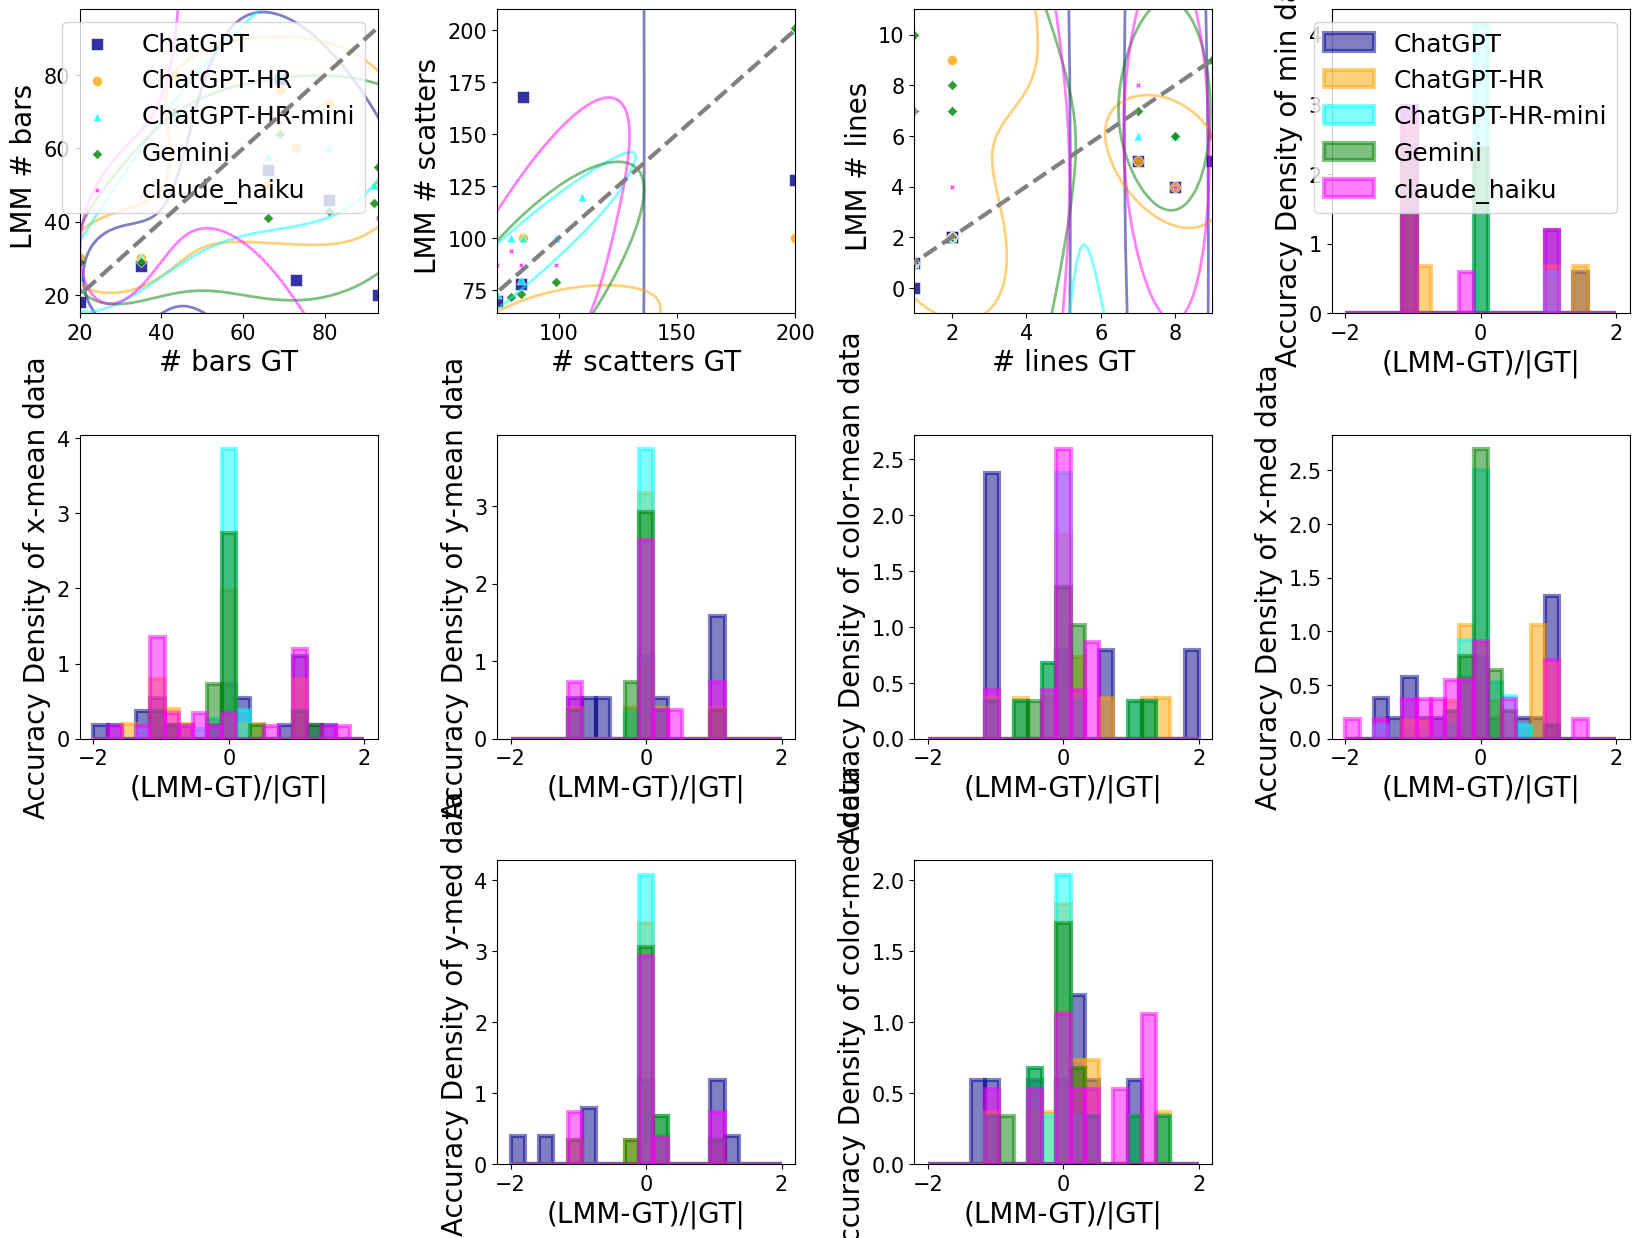

In [20]:
ylims = {'# bars': (-100,100), '# scatters':(-100,100), '# lines':(-10,10)}
questions_plot = questions_figure_plots

import utils.parse_lmm_output_utils
reload(utils.parse_lmm_output_utils)
from utils.parse_lmm_output_utils import get_lmm_gt

base = 5
nx = 1; ny = 3
npanels = nx*ny
fig, axes = make_square_grid_figure_gs(len(questions_plot), figsize_per_plot=(base,base))

levels = [0.5]

fontsize = 20
tick_fontsize = 15
legend_fontsize = 18

eq_linethick = 3
eq_linestyle = '--'
eq_linecolor = 'gray'

hmin = -2
hmax = 2
nbins = 20
hist_bins = np.linspace(hmin,hmax,nbins)
alpha_hist = 0.5
hist_thick = 3

iqset = 0
plot_diffs = False
normalize_diff = False
take_abs = True

hasHistLegend = False
for iq,q in enumerate(questions_plot):
    dfsub = df[df['question']==q['question']]
    for imodel, model in enumerate(dfsub['model'].unique()):
        dfsub2 = dfsub[dfsub['model']==model]
        gt, lmm1 = get_lmm_gt(dfsub2, q['type'])
        gttag = q['tag']+' GT'
        lmtag = labels[model]
        # if plot_diffs:
        #     lmm = (lmm1-gt)
        #     if normalize_diff:
        #         lmm = lmm/gt
        # else:
        lmm = deepcopy(lmm1)
        lmtag_adder = ''
        diffnorm = False
        if 'norm' in q:
            if 'diff':
                if take_abs:
                    lmm = (lmm-gt)/np.abs(gt)
                    lmtag_adder = '(LMM-GT)/|GT|'
                else:
                    lmm = (lmm-gt)/gt
                    lmtag_adder = '(LMM-GT)/GT'

                diffnorm = True
        dfplot = pd.DataFrame({gttag:gt, lmtag:lmm})
        if iq == iqset:
            add_kde_contours(axes[iq], dfplot[gttag], dfplot[lmtag], colors[model], 
                             labels[model], marker_styles[model], marker_sizes[model], 
                             levels=levels, plot_kde=plot_kde)
        else:
            if not diffnorm:
                add_kde_contours(axes[iq], dfplot[gttag], dfplot[lmtag], colors[model], 
                             None, marker_styles[model], marker_sizes[model], 
                             levels=levels, plot_kde=plot_kde)
            else:
                # dfsub2 = dfsub[dfsub['model']==model]
                # gt, lmm = get_lmm_gt(dfsub2, q['type'])
                # diff = (lmm-gt)/gt
                diff = dfplot[lmtag]
                # count NaNs
                print('  the number of NaNs for model', model, '=', len(lmm[np.isnan(lmm)]))
                axes[iq].hist(diff, density=True, bins=hist_bins, label=labels[model], 
                            color=colors[model], alpha=alpha_hist, edgecolor=colors[model], 
                            linewidth=hist_thick)
                axes[iq].set_xlabel(lmtag_adder, fontsize=fontsize)
                axes[iq].set_ylabel('Accuracy Density of '+q['tag'],  fontsize=fontsize)
                if not hasHistLegend:
                    axes[iq].legend()
                    hasHistLegend = True
    #if not plot_diffs:
    if 'yfudge' in q:
        if not diffnorm:
            axes[iq].plot([np.min(gt)-q['yfudge']-10, np.max(gt)+q['yfudge']+10], 
                        [np.min(gt)-q['yfudge']-10, np.max(gt)+q['yfudge']+10], 
                        linestyle=eq_linestyle, linewidth=eq_linethick, zorder=10, 
                        color=eq_linecolor)
            axes[iq].set_ylim(np.min(gt)-q['yfudge'], np.max(gt)+q['yfudge'])
        # else:
        #     axes[iq].set_ylim([q['xlim'][0]-q['yfudge'], q['xlim'][1]+q['yfudge']])
    if not diffnorm:
        axes[iq].set_xlim(np.min(gt), np.max(gt))
        axes[iq].set_ylabel('LMM ' + q['tag'] + ' ' + lmtag_adder, fontsize=fontsize)
        axes[iq].set_xlabel(gttag, fontsize=fontsize)
    # if 'xscale' in q:
    #     axes[iq].set_xscale(q['xscale'])

axes[iqset].legend()


# set font sizes
for ax in axes:
    # Set tick label font sizes for second subplot
    ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
    legend = ax.get_legend()
    if legend is not None:
        # Set legend font size for second subplot
        ax.legend(fontsize=legend_fontsize)


In [21]:
len(lmm1)

14

## Cross-figure

In [22]:
df[df['Level Type']=='Figure-level questions']['question'].unique()

array(['How many panels are in this figure?',
       'What is the plot style used in this figure?',
       'What is the colormap that was used in this figure?',
       'What is the aspect ratio of this figure?',
       'What are the titles for each figure panel?',
       'What are the x-axis titles for each figure panel?',
       'What are the y-axis titles for each figure panel?',
       'What are the values for each of the tick marks on the x-axis?',
       'What are the values for each of the tick marks on the y-axis?',
       'What are the plot types for each panel in the figure?',
       'Which plot shows the largest median data values?',
       'Which plot shows the strongest linear relationship between its x and y values?'],
      dtype=object)

In [23]:
# by number of item
questions_figure_cross = [
    {'tag':'strongest linear', 'question':'Which plot shows the strongest linear relationship between its x and y values?', 'type':'float', 'yfudge':2}, 
    {'tag':'largest median', 'question':'Which plot shows the largest median data values?', 'type':'float', 'yfudge':2}, 
    {'tag':'strongest linear (b)', 'question':'Which plot shows the strongest linear relationship between its x and y values?', 'type':'float', 'yfudge':50, 'norm':'binary diff'}, 
    {'tag':'largest median (b)', 'question':'Which plot shows the largest median data values?', 'type':'float', 'yfudge':50, 'norm':'binary diff'}, 
]

df_question_tags_cross = {}
for t in ['tag', 'question', 'Level', 'Type']:
    df_question_tags_cross[t] = []

/Users/jnaiman/LLM_VQA_MultiPanel/utils/results_plotting_utils.py:344: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()   # now works without warnings
/Users/jnaiman/LLM_VQA_MultiPanel/utils/results_plotting_utils.py:76: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(x=x_data, y=y_data, ax=ax, color=color,
/Users/jnaiman/LLM_VQA_MultiPanel/utils/results_plotting_utils.py:76: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(x=x_data, y=y_data, ax=ax, color=color,
/Users/jnaiman/LLM_VQA_MultiPanel/utils/results_plotting_utils.py:76: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(x=x_data, y=y_data, ax=ax, color=color,
/Users/jnaiman/LL

[WARNING]: have to delete GT to align
[WARNING]: have to delete GT to align
[WARNING]: have to delete GT to align
[WARNING]: have to delete GT to align
[WARNING]: have to delete GT to align
[WARNING]: have to delete GT to align
[WARNING]: have to delete GT to align
[WARNING]: have to delete GT to align
[WARNING]: have to delete GT to align
[WARNING]: have to delete GT to align
[WARNING]: have to delete GT to align
[WARNING]: have to delete GT to align
[WARNING]: have to delete GT to align
[WARNING]: have to delete GT to align
[WARNING]: have to delete GT to align
[WARNING]: have to delete GT to align
[WARNING]: have to delete GT to align
[WARNING]: have to delete GT to align
[WARNING]: have to delete GT to align
[WARNING]: have to delete GT to align


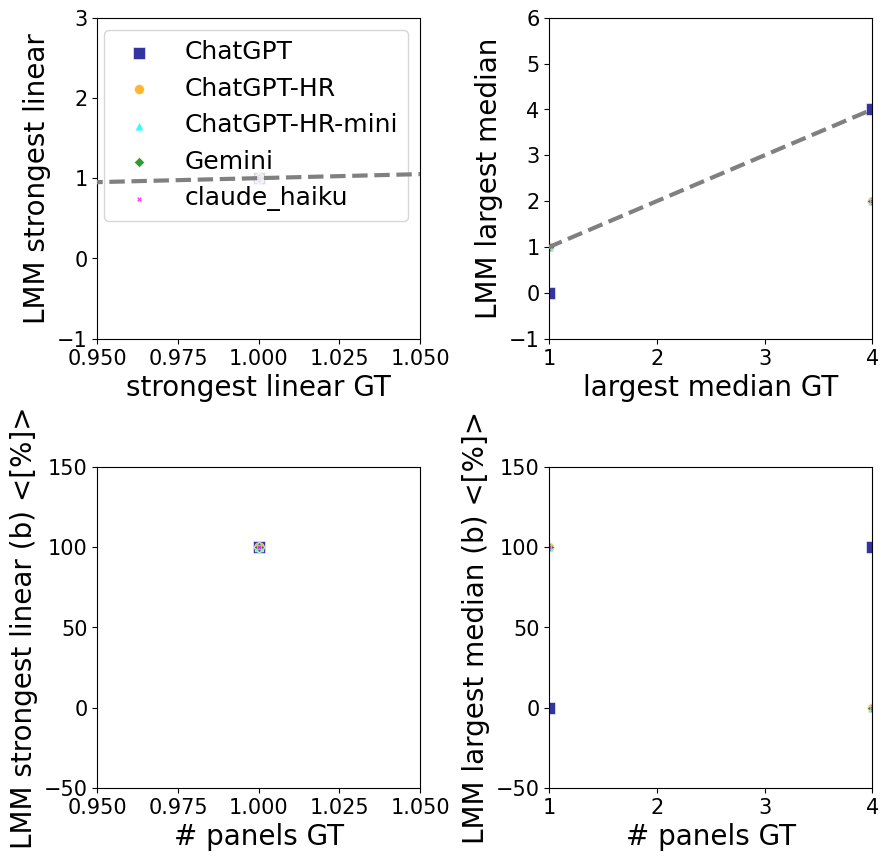

In [24]:
#ylims = {'# bars': (-100,100), '# scatters':(-100,100), '# lines':(-10,10)}
questions_plot = questions_figure_cross

diff_verses = '# panels GT'

import utils.parse_lmm_output_utils
reload(utils.parse_lmm_output_utils)
from utils.parse_lmm_output_utils import get_lmm_gt, align_arrays_safe

base = 5
nx = 1; ny = 3
npanels = nx*ny
fig, axes = make_square_grid_figure_gs(len(questions_plot), figsize_per_plot=(base,base))

levels = [0.5]

fontsize = 20
tick_fontsize = 15
legend_fontsize = 18

eq_linethick = 3
eq_linestyle = '--'
eq_linecolor = 'gray'

hmin = -2
hmax = 2
nbins = 20
hist_bins = np.linspace(hmin,hmax,nbins)
alpha_hist = 0.5
hist_thick = 3

iqset = 0
plot_diffs = False
normalize_diff = False


for iq,q in enumerate(questions_plot):
    dfsub = df[df['question']==q['question']]
    for imodel, model in enumerate(dfsub['model'].unique()):
        dfsub2 = dfsub[dfsub['model']==model]
        gt, lmm1 = get_lmm_gt(dfsub2, q['type'])
        gttag = q['tag']+' GT'
        lmtag = labels[model]
        # if plot_diffs:
        #     lmm = (lmm1-gt)
        #     if normalize_diff:
        #         lmm = lmm/gt
        # else:
        lmm = deepcopy(lmm1)
        lmtag_adder = ''
        diffnorm = False
        binarydiff = False
        if 'norm' in q:
            if q['norm']=='diff':
                lmm = (lmm-gt)/np.abs(gt)
                lmtag_adder = ' (LMM-GT)/|GT|'
                diffnorm = True
            elif q['norm']=='binary diff':
                if diff_verses == '# panels GT':
                    gtp = []
                    for g in dfsub2['image id'].values:
                        with open(dir_jsons + g +'.json', 'r') as f:
                            dd = json.load(f)
                            dd = json.loads(dd)
                        dd = dd['figure']
                        gtp.append(dd['nrows']*dd['ncols'])
                    gttag = '# panels GT'
                    # now deposit diff binaries on gttag
                    if len(gt) > len(lmm):
                        lmm1 = align_arrays_safe(gt,lmm)
                    elif len(lmm) > len(gt):
                        gt = align_arrays_save(lmm,gt)
                    else:
                        lmm1 = lmm
                    lmm=[]
                    for g,l in zip(gt,lmm1):
                        if g == l:
                            lmm.append(1)
                        else:
                            lmm.append(0)
                    d = pd.DataFrame({gttag:gt, lmtag:lmm})
                    # deposit
                    gd = d.groupby(gttag)[lmtag].mean()
                    gt = gd.index; lmm = gd.values*100
                    lmtag_adder = " <[%]>"
                    binarydiff = True

        dfplot = pd.DataFrame({gttag:gt, lmtag:lmm})
        if iq == iqset:
            add_kde_contours(axes[iq], dfplot[gttag], dfplot[lmtag], colors[model], 
                             labels[model], marker_styles[model], marker_sizes[model], 
                             levels=levels, plot_kde=plot_kde)
        else:
            if not diffnorm:
                add_kde_contours(axes[iq], dfplot[gttag], dfplot[lmtag], colors[model], 
                             None, marker_styles[model], marker_sizes[model], 
                             levels=levels, plot_kde=plot_kde)
            else:
                diff = dfplot[lmtag]
                # count NaNs
                print('  the number of NaNs for model', model, '=', len(lmm[np.isnan(lmm)]))
                axes[iq].hist(diff, density=True, bins=hist_bins, label=labels[model], 
                            color=colors[model], alpha=alpha_hist, edgecolor=colors[model], 
                            linewidth=hist_thick)
                axes[iq].set_xlabel('(LMM-GT)/|GT|', fontsize=fontsize)
                axes[iq].set_ylabel('Accuracy Density of '+q['tag'],  fontsize=fontsize)
                axes[iq].legend()
    #if not plot_diffs:
    if 'yfudge' in q:
        if not diffnorm and not binarydiff:
            axes[iq].plot([np.min(gt)-q['yfudge']-10, np.max(gt)+q['yfudge']+10], 
                        [np.min(gt)-q['yfudge']-10, np.max(gt)+q['yfudge']+10], 
                        linestyle=eq_linestyle, linewidth=eq_linethick, zorder=10, 
                        color=eq_linecolor)
            axes[iq].set_ylim(np.min(gt)-q['yfudge'], np.max(gt)+q['yfudge'])
        if binarydiff:
            axes[iq].set_ylim(0-q['yfudge'], 100+q['yfudge'])
        # else:
        #     axes[iq].set_ylim([q['xlim'][0]-q['yfudge'], q['xlim'][1]+q['yfudge']])
    if not diffnorm:
        axes[iq].set_xlim(np.min(gt), np.max(gt))
        axes[iq].set_ylabel('LMM ' + q['tag'] + lmtag_adder, fontsize=fontsize)
        axes[iq].set_xlabel(gttag, fontsize=fontsize)
    # if 'xscale' in q:
    #     axes[iq].set_xscale(q['xscale'])

axes[iqset].legend()


# set font sizes
for ax in axes:
    # Set tick label font sizes for second subplot
    ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
    legend = ax.get_legend()
    if legend is not None:
        # Set legend font size for second subplot
        ax.legend(fontsize=legend_fontsize)


In [25]:
gd

# panels GT
1.0    1.0
4.0    0.0
Name: claude_haiku, dtype: float64

## Plot-level, Level 2 & 3, Scatter-plot specific

In [26]:
# Level 2
df[(df['Level Type']=='Plot-level questions') & (df['Level'] == 'Level 2')]['question'].unique()

array(['What is the maximum value of the data in this figure panel?',
       'What is the maximum value of the data along the color-axis in this figure panel?',
       'What is the maximum value of the data along the x-axis in this figure panel?',
       'What is the maximum value of the data along the y-axis in this figure panel?',
       'What is the mean value of the data in this figure panel?',
       'What is the mean value of the data along the color-axis in this figure panel?',
       'What is the mean value of the data along the x-axis in this figure panel?',
       'What is the mean value of the data along the y-axis in this figure panel?',
       'What is the median value of the data in this figure panel?',
       'What is the median value of the data along the color-axis in this figure panel?',
       'What is the median value of the data along the x-axis in this figure panel?',
       'What is the median value of the data along the y-axis in this figure panel?',
       'Wha

In [27]:
# Level 3
df[(df['Level Type']=='Plot-level questions') & (df['Level'].isin(['Level 2', 'Level 3']))]['question'].unique()

array(['What is the maximum value of the data in this figure panel?',
       'What is the maximum value of the data along the color-axis in this figure panel?',
       'What is the maximum value of the data along the x-axis in this figure panel?',
       'What is the maximum value of the data along the y-axis in this figure panel?',
       'What is the mean value of the data in this figure panel?',
       'What is the mean value of the data along the color-axis in this figure panel?',
       'What is the mean value of the data along the x-axis in this figure panel?',
       'What is the mean value of the data along the y-axis in this figure panel?',
       'What is the median value of the data in this figure panel?',
       'What is the median value of the data along the color-axis in this figure panel?',
       'What is the median value of the data along the x-axis in this figure panel?',
       'What is the median value of the data along the y-axis in this figure panel?',
       'Wha

for qtag: color mean
ChatGPT
[WARNING]: have to delete GT to align
  the number of NaNs for model ChatGPT = 2
ChatGPT-HR
[WARNING]: have to delete GT to align
  the number of NaNs for model ChatGPT-HR = 0
ChatGPT-HR-mini
[WARNING]: have to delete GT to align
  the number of NaNs for model ChatGPT-HR-mini = 0
Gemini
[WARNING]: have to delete GT to align
  the number of NaNs for model Gemini = 0
claude_haiku
[WARNING]: have to delete GT to align
  the number of NaNs for model claude_haiku = 0


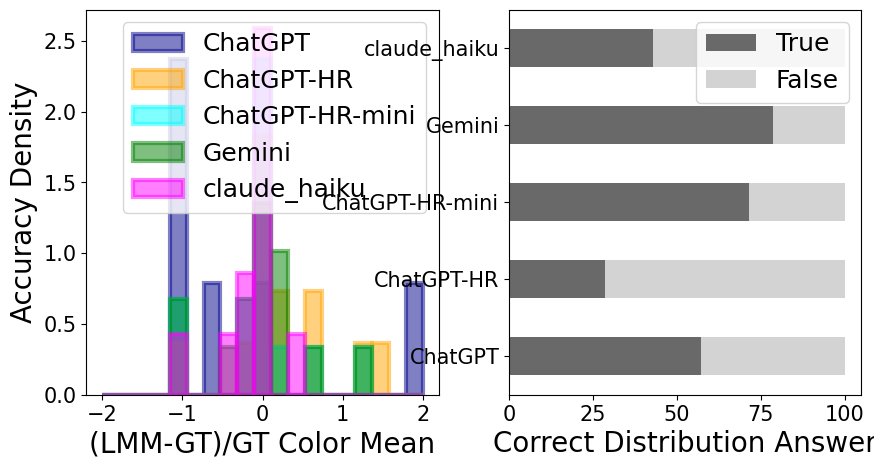

In [28]:
# figure-level questions
questions_figure = [
    {'tag':'color mean', 'question':'What is the mean value of the data along the color-axis in this figure panel?', #'What is the mean value of the data along the color-axis in this figure panel? ', 
        'type':'float', 'yfudge':5},
    {'tag':'color dist', 'question':'What is the underlying distribution used to create the data in this figure panel along the color-axis?', 
     'type':'binary string', 'use list':True, 'yfudge':5}

]


base = 5
nx = 1; ny = 2
npanels = nx*ny
fig, axes = plt.subplots(1,npanels, figsize=(base*npanels,base))
levels = [0.5]

fontsize = 20
tick_fontsize = 15
legend_fontsize = 18

eq_linethick = 3
eq_linestyle = '--'
eq_linecolor = 'gray'


colors_bar = ['dimgray', 'lightgray']

iqset = 0
plot_diffs = False
normalize_diff = False
# iqset = 2
# plot_diffs = True
# normalize_diff = True

hmin = -2
hmax = 2
nbins = 20
hist_bins = np.linspace(hmin,hmax,nbins)
alpha_hist = 0.5
hist_thick = 3

for iq,q in enumerate(questions_figure):
    dfsub = df[df['question']==q['question']]
    if q['type'] == 'float': # for example, mean color
        d = {}
        print('for qtag:', q['tag'])
        for imodel, model in enumerate(dfsub['model'].unique()):
            print(model)
            dfsub2 = dfsub[dfsub['model']==model]
            gt, lmm = get_lmm_gt(dfsub2, q['type'])
            diff = (lmm-gt)/gt
            # count NaNs
            print('  the number of NaNs for model', model, '=', len(lmm[np.isnan(lmm)]))
            axes[iq].hist(diff, density=True, bins=hist_bins, label=labels[model], 
                          color=colors[model], alpha=alpha_hist, edgecolor=colors[model], 
                          linewidth=hist_thick,)
            axes[iq].set_xlabel('(LMM-GT)/GT Color Mean', fontsize=fontsize)
            axes[iq].set_ylabel('Accuracy Density',  fontsize=fontsize)
            axes[iq].legend()

    elif q['type'] == 'binary string':
        d = {}
        for imodel, model in enumerate(dfsub['model'].unique()):
            dfsub2 = dfsub[dfsub['model']==model]
            gt, lmm = get_lmm_gt(dfsub2, q['type'])
            diff = []
            for g,l in zip(gt,lmm):
                if g.lower().replace(' ', '').strip() == l.lower().replace(' ', '').strip():
                    diff.append(1)
                else:
                    diff.append(0)
            d[labels[model]] = deepcopy(diff)
        d = pd.DataFrame(d)
        models_category = list(d.keys())
        true_count = []; false_count = []
        for m in models_category:
            dsub = d[m].values
            true_count.append(len(dsub[dsub==1]))
            false_count.append(len(dsub[dsub==0]))
        data = {
            'Model':models_category,
            'True':np.array(true_count)*1.0/len(dsub)*100,
            'False':np.array(false_count)*1.0/len(dsub)*100
        }
        dfplot = pd.DataFrame(data)
        # colors_bar = []
        # for k,v in colors.items():
        #     for i in range(2):
        #         colors_bar.append(v)
        dfplot.plot(
            x='Model', 
            y=['True', 'False'], 
            kind='barh', 
            stacked=True, 
            ax=axes[iq],
            color=colors_bar
        )
        #import sys; sys.exit()
        axes[iq].set_ylabel('')
        axes[iq].set_xlabel('Correct Distribution Answer',  fontsize=fontsize)




# set font sizes
for ax in axes:
    # Set tick label font sizes for second subplot
    ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
    legend = ax.get_legend()
    if legend is not None:
        # Set legend font size for second subplot
        ax.legend(fontsize=legend_fontsize)

# fig.tight_layout()

# divT = ''
# if not plot_diffs:
#     divT = '_notDiv'
# fig.savefig(save_fig_dir + 'plotLevel_L23_scatters'+divT+'.pdf')
# plt.show()


Features of histogram:
* spike around 0 is when the LMM is guessing right
* The spike in the histogram around -1 means the histogram is guessing either 0.0 or 0.5 and the GT mean is significantly larger so the calculation is basically just -GT/GT = -1
* for qtag: color mean
  * the number of NaNs for model claude = 1
  * the number of NaNs for model gemini_1.5 = 0
  * the number of NaNs for model chatgpt = 34

In [29]:
dfplot

,Model,True,False
0,ChatGPT,57.142857,42.857143
1,ChatGPT-HR,28.571429,71.428571
2,ChatGPT-HR-mini,71.428571,28.571429
3,Gemini,78.571429,21.428571
4,claude_haiku,42.857143,57.142857
